In [3]:
import numpy as np 
import matplotlib.pyplot as plt 

In [5]:
Nind = 100
Lind = 33
Pc = 0.9
Pm = 0.01
Maxgen = 1000
Nvar = 2 
rango = np.array([[-3,4.1],[12.1,5.8]])

In [7]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

In [8]:
def decodifica(genotipo, rango):
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar          # bits por variable
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)])

    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / (2 ** Lvar - 1)) * fenotipo[:, i]

    return fenotipo

In [9]:
def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))

    for i in range(Nind):
        objv[i, 0] = (21.5
                      + fenotipo[i, 0] * np.sin(4 * np.pi * fenotipo[i, 0])
                      + fenotipo[i, 1] * np.sin(20 * np.pi * fenotipo[i, 1]))
    return objv

In [10]:
def rankeo(objv, direccion):
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        nuevo_objv = np.sort(objv, axis=0)
    else:
        nuevo_objv = np.sort(-1 * objv, axis=0)

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(nuevo_objv, axis=0).flatten()
    aptitud[posori, 0] = apt

    return aptitud

In [11]:
def ruleta(genotipo, fenotipo, aptitud):
    Nind, _ = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros(Nind, dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i] = aux[0]

    return genotipo[idx, :]

In [12]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy().astype(float)
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :]     = np.concatenate((nuevo_gen[i, :corte],     nuevo_gen[i+1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i+1, :corte],   nuevo_gen[i, corte:]))

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    return aux_gen.astype(int)

In [13]:
def muta(nuevo_gen, Pm):
    valores = np.random.rand(*nuevo_gen.shape)
    mascara = valores <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

In [14]:
np.random.seed(42)  # Para reproducibilidad

# Población inicial
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv     = objfun(fenotipo)

# Arreglos para guardar historial
Mejor           = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

# ── Ciclo evolutivo ──
generaciones = 1

while generaciones < Maxgen:
    aptitud   = rankeo(objv, 1)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)

    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    # Guardar el mejor de esta generación
    idx = np.argmax(nuevo_objv)
    Mejor[generaciones]              = nuevo_objv[idx]
    Mejor_cromosoma[generaciones, :] = nuevo_gen[idx, :]

    # Reemplazar población
    genotipo = nuevo_gen
    objv     = nuevo_objv
    fenotipo = nuevo_feno

    generaciones += 1

print("✅ Ciclo evolutivo terminado")

✅ Ciclo evolutivo terminado


In [15]:
mejor_gen   = np.nanargmax(Mejor)
mejor_valor = Mejor[mejor_gen, 0]
mejor_cromo = Mejor_cromosoma[mejor_gen, :]
mejor_feno  = decodifica(mejor_cromo.reshape(1, -1), rango)

print("=" * 45)
print(f"  Mejor valor f(x,y) : {mejor_valor:.4f}")
print(f"  En generación      : {mejor_gen}")
print(f"  x = {mejor_feno[0,0]:.4f}")
print(f"  y = {mejor_feno[0,1]:.4f}")
print("=" * 45)

  Mejor valor f(x,y) : 36.4632
  En generación      : 916
  x = 3.6092
  y = 11.5229


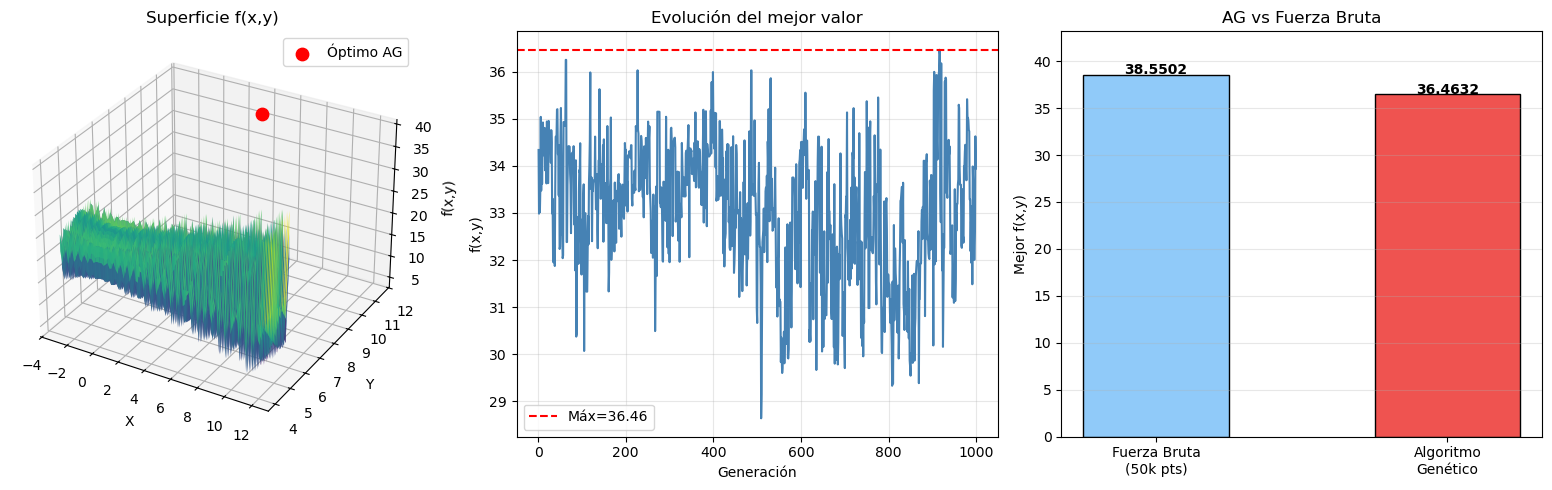

In [16]:
fig = plt.figure(figsize=(16, 5))

# 1) Superficie 3D
ax1 = fig.add_subplot(131, projection='3d')
x_v = np.linspace(-3, 12.1, 100)
y_v = np.linspace(4.1, 5.8, 100)
X, Y = np.meshgrid(x_v, y_v)
Z = 21.5 + X * np.sin(4 * np.pi * X) + Y * np.sin(20 * np.pi * Y)
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)
ax1.scatter(mejor_feno[0,0], mejor_feno[0,1], mejor_valor,
            color='red', s=80, label='Óptimo AG')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('f(x,y)')
ax1.set_title('Superficie f(x,y)')
ax1.legend()

# 2) Evolución por generación
ax2 = fig.add_subplot(132)
gens = np.where(~np.isnan(Mejor[:,0]))[0]
ax2.plot(gens, Mejor[gens, 0], color='steelblue', lw=1.5)
ax2.axhline(mejor_valor, color='red', linestyle='--', label=f'Máx={mejor_valor:.2f}')
ax2.set_xlabel('Generación'); ax2.set_ylabel('f(x,y)')
ax2.set_title('Evolución del mejor valor')
ax2.legend(); ax2.grid(True, alpha=0.3)

# 3) Comparación AG vs Fuerza Bruta
ax3 = fig.add_subplot(133)
x_fb = np.random.uniform(-3, 12.1, 50000)
y_fb = np.random.uniform(4.1, 5.8, 50000)
mejor_fb = np.max(21.5 + x_fb * np.sin(4*np.pi*x_fb) + y_fb * np.sin(20*np.pi*y_fb))

bars = ax3.bar(['Fuerza Bruta\n(50k pts)', 'Algoritmo\nGenético'],
               [mejor_fb, mejor_valor],
               color=['#90CAF9','#EF5350'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [mejor_fb, mejor_valor]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.4f}', ha='center', fontweight='bold')
ax3.set_ylabel('Mejor f(x,y)')
ax3.set_title('AG vs Fuerza Bruta')
ax3.set_ylim(0, max(mejor_fb, mejor_valor) * 1.12)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()